
TFG

Este es el codigo del tfg de Borja Jimeno

In [1]:
import sys            # módulo para interactuar con el intérprete
import os             # módulo para operaciones del sistema de archivos

import numpy as np
import math as m
import matplotlib.pyplot as plt
from scipy import special
from scipy.stats import norm

import re

path="/home/borja/Documents/TFG/GeneraRitmo/Libs/ANAIS"
sys.path.append(path)

from funciones_ritmo_teorico import*
from funciones_ritmo_exp import*

plt.rcParams['font.size'] = 18

In [2]:

import sys            
import os             
import numpy as np
import math as m
import matplotlib.pyplot as plt
from scipy import special
from scipy.stats import norm
import re
import numpy as np
import uproot


def carga_datos_hist(titulo,archivo):
    file = uproot.open(archivo)
    file.keys()
    longitud=36*4
    datos=np.zeros((2,longitud))
    
    graph = file[titulo]
    datos[0]=graph.member("fX")
    datos[1]=graph.member("fY")
    
    return datos


Datos_DM_16=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_DM_SG_SI","SI_fix_1.root")
Datos_DM_16_ANOD=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_ANOD_DM_SG_SI","SI_fix_1.root")

DM_16=Datos_DM_16[1]
DM_16_ANOD=Datos_DM_16_ANOD[1]

DM_16_m=Datos_DM_16[0]
DM_16_ANOD_m=Datos_DM_16_ANOD[0]


Datos_DM_26=carga_datos_hist("gA112_6y_90_2.000000_6.000000_QFtamara_DM_SG_SI","SI_fix_1.root")
Datos_DM_26_ANOD=carga_datos_hist("gA112_6y_90_2.000000_6.000000_QFtamara_ANOD_DM_SG_SI","SI_fix_1.root")

DM_26=Datos_DM_26[1]
DM_26_ANOD=Datos_DM_26_ANOD[1]

DM_26_m=Datos_DM_26[0]
DM_26_ANOD_m=Datos_DM_26_ANOD[0]

masas_ref=Datos_DM_26[0]

Datos_DM_8y_16=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_DM_SG_SI;4","SI_8y.root")

DM_16_8y=Datos_DM_8y_16[1]

DM_16_8y_m=Datos_DM_8y_16[0]



In [3]:
def elimina_sing(array_d,array_m):
    aa=0
    while(aa==0):
        if (array_d[0]<0 or array_d[0]>1):
            array_d=np.delete(array_d,0)
            array_m=np.delete(array_m,0)
        else:
            aa=1
    return array_d,array_m

DM_16, DM_16_m = elimina_sing(DM_16,DM_16_m)

DM_16_ANOD, DM_16_ANOD_m = elimina_sing(DM_16_ANOD,DM_16_ANOD_m)

DM_26, DM_26_m = elimina_sing(DM_26,DM_26_m)

DM_26_ANOD, DM_26_ANOD_m = elimina_sing(DM_26_ANOD,DM_26_ANOD_m)

DM_16_8y, DM_16_8y_m = elimina_sing(DM_16_8y,DM_16_8y_m)



In [4]:
DAMA1=np.loadtxt("DAMA1.txt")

DAMA1_x=[]
DAMA1_y=[]

for i in range(len(DAMA1)):
    DAMA1_x.append(DAMA1[i][0])
    DAMA1_y.append(DAMA1[i][1])

DAMA2=np.loadtxt("DAMA2.txt")

DAMA2_x=[]
DAMA2_y=[]

for i in range(len(DAMA2)):
    DAMA2_x.append(DAMA2[i][0])
    DAMA2_y.append(DAMA2[i][1])



COSINE=np.loadtxt("COSINE-100.txt")

COSINE_x=[]
COSINE_y=[]

for i in range(len(COSINE)):
    COSINE_x.append(COSINE[i][0])
    COSINE_y.append(COSINE[i][1])

ANAIS_SF=np.loadtxt("SI_SF.txt")

ANAIS_SF_x=[]
ANAIS_SF_y=[]

for i in range(len(ANAIS_SF)):
    ANAIS_SF_x.append(ANAIS_SF[i][0])
    ANAIS_SF_y.append(ANAIS_SF[i][1])


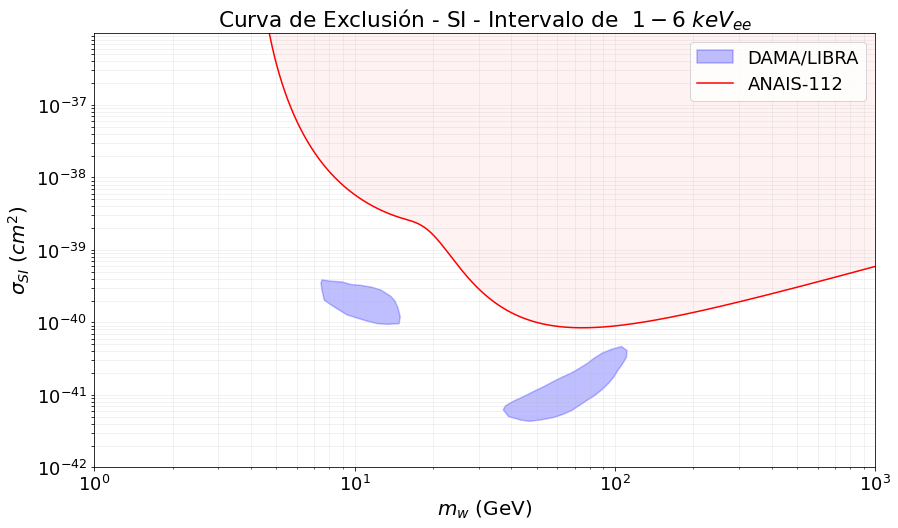

In [27]:
plt.figure(figsize=(14, 8), facecolor='white')  # Fondo blanco de la figura
ax = plt.subplot()
ax.set_facecolor('white')  # Fondo blanco del área de los ejes


ax.fill(DAMA1_x, DAMA1_y, facecolor='blue', alpha=0.25, edgecolor='blue', linewidth=1.5, label="DAMA/LIBRA")
ax.fill(DAMA2_x, DAMA2_y, facecolor='blue', alpha=0.25, edgecolor='blue', linewidth=1.5)

#ax.plot(COSINE_x,COSINE_y,c='black',linestyle="--",label="COSINE (2018)")

ax.plot(ANAIS_SF_x,ANAIS_SF_y,linestyle='-',label="ANAIS-112", alpha=1,c="red")
ax.fill_between(ANAIS_SF_x, ANAIS_SF_y, 1e-36, color='red', alpha=0.05)
#ax.plot(DM_16_m,DM_16, linestyle='-',label="1-6 $keV_{ee}$", alpha=1,c="red")
#ax.plot(DM_16_ANOD_m,DM_16_ANOD , linestyle='-', label="1-6 $keV_{ee}$ - ANOD", alpha=1,c="green")

ax.legend()

ax.set_title(r'Curva de Exclusión - SI - Intervalo de  $1-6$ $keV_{ee}$')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-36
y_inf=1e-42

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

plt.savefig("SinFondoSI.pdf", dpi=150, facecolor='white')


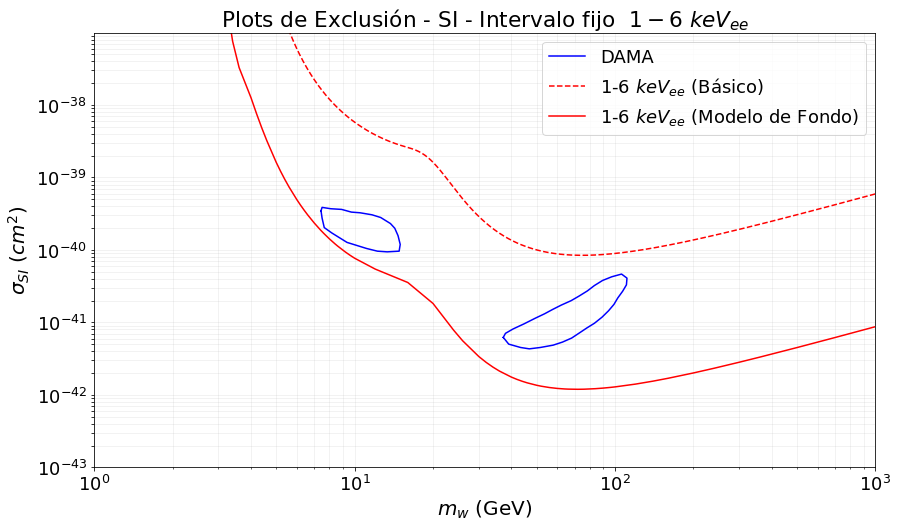

In [6]:
plt.figure(figsize=(14, 8), facecolor='white')  # Fondo blanco de la figura
ax = plt.subplot()
ax.set_facecolor('white')  # Fondo blanco del área de los ejes


ax.plot(DAMA1_x,DAMA1_y,c='blue',label="DAMA")
ax.plot(DAMA2_x,DAMA2_y,c='blue')

#ax.plot(COSINE_x,COSINE_y,c='black',linestyle="--",label="COSINE (2018)")

ax.plot(ANAIS_SF_x,ANAIS_SF_y,linestyle='--',label="1-6 $keV_{ee}$ (Básico)", alpha=1,c="red")

ax.plot(DM_16_m,DM_16, linestyle='-',label="1-6 $keV_{ee}$ (Modelo de Fondo)", alpha=1,c="red")
#ax.plot(DM_16_ANOD_m,DM_16_ANOD , linestyle='-', label="1-6 $keV_{ee}$ - ANOD", alpha=1,c="green")

ax.legend()

ax.set_title(r'Plots de Exclusión - SI - Intervalo fijo  $1-6$ $keV_{ee}$')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-37
y_inf=1e-43

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

plt.savefig("SinFondoSI_2.svg", dpi=150, facecolor='white')


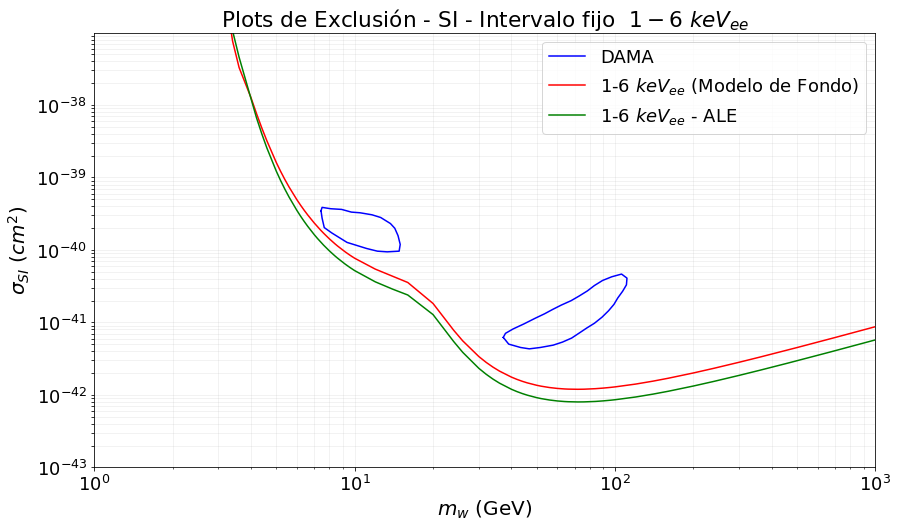

In [7]:
plt.figure(figsize=(14, 8), facecolor='white')  # Fondo blanco de la figura
ax = plt.subplot()
ax.set_facecolor('white')  # Fondo blanco del área de los ejes


ax.plot(DAMA1_x,DAMA1_y,c='blue',label="DAMA")
ax.plot(DAMA2_x,DAMA2_y,c='blue')

#ax.plot(COSINE_x,COSINE_y,c='black',linestyle="--",label="COSINE (2018)")

#ax.plot(ANAIS_SF_x,ANAIS_SF_y,linestyle='--',label="1-6 $keV_{ee}$ (Básico)", alpha=1,c="red")

ax.plot(DM_16_m,DM_16, linestyle='-',label="1-6 $keV_{ee}$ (Modelo de Fondo)", alpha=1,c="red")
ax.plot(DM_16_ANOD_m,DM_16_ANOD , linestyle='-', label="1-6 $keV_{ee}$ - ALE", alpha=1,c="green")

ax.legend()

ax.set_title(r'Plots de Exclusión - SI - Intervalo fijo  $1-6$ $keV_{ee}$')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-37
y_inf=1e-43

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

plt.savefig("SinFondoSI_3.svg", dpi=150, facecolor='white')


In [8]:
m=DM_16_ANOD_m
s=DM_16_ANOD

fichero = open("SI_1_6_Tamara.txt", 'w')
# Guardamos la lista en el fichero
for i in range(len(m)):
    fichero.write(f"{m[i]} \t {s[i]} \n")

# Cerramos el fichero
fichero.close()

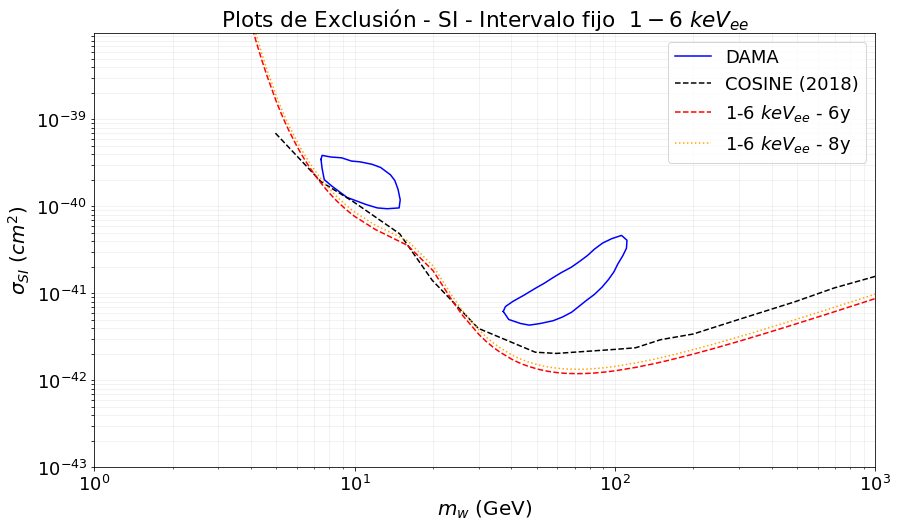

In [9]:
plt.figure(figsize=(14, 8), facecolor='white')

ax = plt.subplot()
ax.set_facecolor('white')  # Fondo blanco del área de los ejes

ax.plot(DAMA1_x,DAMA1_y,c='blue',label="DAMA")
ax.plot(DAMA2_x,DAMA2_y,c='blue')

ax.plot(COSINE_x,COSINE_y,c='black',linestyle="--",label="COSINE (2018)")

ax.plot(DM_16_m,DM_16, linestyle='--',label="1-6 $keV_{ee}$ - 6y", alpha=1,c="red")
ax.plot(DM_16_8y_m,DM_16_8y , linestyle=':', label="1-6 $keV_{ee}$ - 8y", alpha=1,c="orange")

ax.legend()

ax.set_title(r'Plots de Exclusión - SI - Intervalo fijo  $1-6$ $keV_{ee}$')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-38
y_inf=1e-43

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)


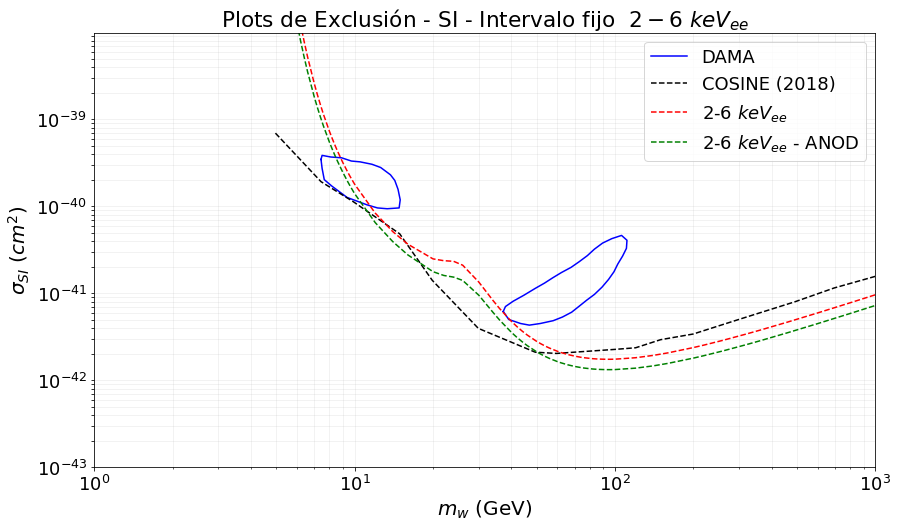

In [10]:
plt.figure(figsize=(14, 8))
ax = plt.subplot()

ax.plot(DAMA1_x,DAMA1_y,c='blue',label="DAMA")
ax.plot(DAMA2_x,DAMA2_y,c='blue')

ax.plot(COSINE_x,COSINE_y,c='black',linestyle="--",label="COSINE (2018)")

ax.plot(DM_26_m,DM_26, linestyle='--',label="2-6 $keV_{ee}$", alpha=1,c="red")
ax.plot(DM_26_ANOD_m,DM_26_ANOD , linestyle='--', label="2-6 $keV_{ee}$ - ANOD", alpha=1,c="green")

ax.legend()

ax.set_title(r'Plots de Exclusión - SI - Intervalo fijo  $2-6$ $keV_{ee}$')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-38
y_inf=1e-43

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)


In [11]:
m=DM_26_ANOD_m
s=DM_26_ANOD

fichero = open("SI_2_6_Tamara.txt", 'w')
# Guardamos la lista en el fichero
for i in range(len(m)):
    fichero.write(f"{m[i]} \t {s[i]} \n")

# Cerramos el fichero
fichero.close()

In [12]:
def imprime_plot(e_i,e_s,tipo,print_plot=0):
    
    nombre=""

    prin1="gA112_6y_90_"
    prin2="_QFtamara_"

    modos=("DM_SG_SI","PY_SI","RA_SI","WI_SI","DMA_SI")

    nombre=prin1+f'{e_i:.6f}'+"_"+f'{e_s:.6f}'+prin2+modos[tipo]

    file = uproot.open("SI_varios_intervalos.root")
    graph = file[nombre]

    
    x_aux=graph.member("fX")
    y_aux=graph.member("fY")
    
    x=[]
    y=[]

    for i in range(len(x_aux)):
        if y_aux[i]<1e-35:
            if y_aux[i]>1e-55:
                x.append(x_aux[i])
                y.append(y_aux[i])

                

    
    if print_plot==1:
            plt.figure(figsize=(14, 8))
            ax = plt.subplot()

            ax.plot(x,y)


            #ax.legend()
            ax.set_title(r'Plots de Exlusión - $\sigma_{SI}$  en función de $m_w$ (GeV)')
            ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
            ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

            ax.set_yscale("log")
            ax.set_xscale("log")

            y_sup=1e-35
            y_inf=1e-45

            ax.set_ylim(y_inf,y_sup)
            ax.set_xlim(1,1000)

            exp_min = int(np.floor(np.log10(y_inf)))   
            exp_max = int(np.ceil(np.log10(y_sup)))    
            exps = np.arange(exp_min, exp_max)     


            all_ticks = []
            for e in exps:
                decade = (np.arange(1, 10) * (10.0**e)).tolist()
                all_ticks.extend(decade)
            all_ticks = np.array(all_ticks)

            ax.set_yticks(all_ticks)                    

            ax.grid(which='both', linestyle='-', alpha=0.2)

    return x,y

def encuentra_intervalo(cadena):
    valores = re.findall(r"\d+\.\d+", cadena)
    a=np.zeros(2)
    a[0]=float(valores[0])
    a[1]=float(valores[1])
    return a

def genera_lista_modos(lista_modos):
    lista_ref=(0,1,2,3,4)
    lista_ref=np.array(lista_ref)
    if (type(lista_modos)==int):
        a=np.where(lista_ref == lista_modos,1,0)
        return a
        
    else:
        lista_modos=np.array(lista_modos)
        a=np.zeros(len(lista_ref),dtype=int)
        for i in range (len(lista_modos)):
            a+=np.where(lista_ref == lista_modos[i],1,0)
        return a

def lista_intervalo(lista_energias,anod_bool):
    
    list_names=[]
    list_energies=[]

    prin1="gA112_6y_90_"
    prin2="_QFtamara_"
    
    if anod_bool==0:
        modos="DM_SG_SI"

    if anod_bool==1:
        modos="ANOD_DM_SG_SI"
    

    for i in range (len(lista_energias)):
            intervalo_minimo=np.zeros(2)
            list_names.append(prin1+f'{lista_energias[i][0]:.6f}'+"_"+f'{lista_energias[i][1]:.6f}'+prin2+modos)
            intervalo_minimo[0]=lista_energias[i][0]
            intervalo_minimo[1]=lista_energias[i][1]
            list_energies.append(intervalo_minimo)


    return list_names, list_energies

def carga_datos_hist(lista_energias,anod_bool,filename):

    lista_nombres, list_energies=lista_intervalo(lista_energias,anod_bool)
    
    file = uproot.open(filename)
    
    datos=[]
    intervalos=[]
    resultado=[]

    for i in range(len(lista_nombres)):

        valores=list_energies[i]
        nombre=lista_nombres[i]

        graph = file[nombre]
        
        masas=graph.member("fX")
        valores=graph.member("fY")

        valores, masas = elimina_sing(valores,masas)

        aux=np.ones((2,len(valores)))

        aux[0]=masas
        aux[1]=valores

        datos.append(aux)
        intervalos.append(valores)
    
    resultado.append(datos)
    resultado.append(intervalos)
    return resultado, lista_nombres

def minimiza_lista_datos(lista_datos,lista_energias,array_masas):
    
    
    masas=[]
    sigmas=[]
    int_min=[]

   

    for m in masas_ref:
        sigma_aux=1
        masa_ref=0
        intervalo_minimo=np.zeros(2)
        
        for j in range (len(lista_datos[1])):
            a=0

            a=np.where(lista_datos[0][j][0]==m,lista_datos[0][j][1],0)
            a_norm=np.linalg.norm(a)

            if(a_norm!=0):
                masa_ref=1
                if(a_norm<sigma_aux):
                    sigma_aux=a_norm
                    intervalo_minimo[0]=lista_energias[j][0]
                    intervalo_minimo[1]=lista_energias[j][1]
    
        if masa_ref==1:
            sigmas.append(sigma_aux)
            masas.append(m)
            int_min.append(intervalo_minimo)

    return masas,sigmas,int_min

def imprime_intervalo_optimo(masas,intervalo_minimo):
    for i in range (len(masas)):
        print(f'Mass: {masas[i]:.1f} GeV - Minimum Exlussion Interval:  ({intervalo_minimo[i][0]} - {intervalo_minimo[i][1]}) keV ')

In [13]:
lista_energias= np.loadtxt('list_energies_SI.txt')

lista_datos, lista_nombres=carga_datos_hist(lista_energias,0,'SI_int_1.root')

masas_opt,sigmas_opt,intervalo_minimo=minimiza_lista_datos(lista_datos,lista_energias,masas_ref)

imprime_intervalo_optimo(masas_opt,intervalo_minimo)


Mass: 2.2 GeV - Minimum Exlussion Interval:  (2.0 - 3.0) keV 
Mass: 2.4 GeV - Minimum Exlussion Interval:  (2.0 - 5.0) keV 
Mass: 2.6 GeV - Minimum Exlussion Interval:  (2.0 - 6.0) keV 
Mass: 3.0 GeV - Minimum Exlussion Interval:  (2.0 - 3.0) keV 
Mass: 3.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 3.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 3.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 4.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 6.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 6.

In [14]:
lista_energias_ANOD = np.loadtxt('list_energies_SI_ANOD.txt')

lista_datos_ANOD, lista_nombres_ANOD=carga_datos_hist(lista_energias_ANOD,1,'SI_int_1.root')

masas_opt_ANOD,sigmas_opt_ANOD,intervalo_minimo_ANOD=minimiza_lista_datos(lista_datos_ANOD,lista_energias_ANOD,masas_ref)

imprime_intervalo_optimo(masas_opt_ANOD,intervalo_minimo_ANOD)

Mass: 2.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 2.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 2.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 3.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 3.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 3.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 3.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 4.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 6.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 6.

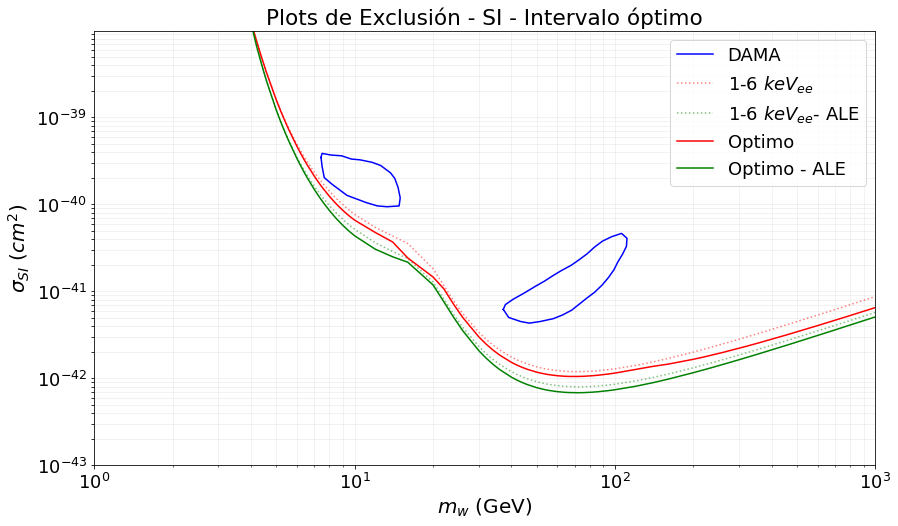

In [15]:
plt.figure(figsize=(14, 8), facecolor='white')  # Fondo blanco de la figura
ax = plt.subplot()
ax.set_facecolor('white')  # Fondo blanco del área de los ejes

ax.plot(DAMA1_x,DAMA1_y,c='blue',label="DAMA")
ax.plot(DAMA2_x,DAMA2_y,c='blue')

#ax.plot(COSINE_x,COSINE_y,c='black',linestyle="--",label="COSINE (2018)")

ax.plot(DM_16_m,DM_16, linestyle=':',label="1-6 $keV_{ee}$",c="red",alpha=0.5)
ax.plot(DM_16_ANOD_m,DM_16_ANOD , linestyle=':', label="1-6 $keV_{ee}$- ALE",c="green",alpha=0.5)



ax.plot(masas_opt,sigmas_opt, linestyle='-', label="Optimo", alpha=1,c="red")
ax.plot(masas_opt_ANOD,sigmas_opt_ANOD, linestyle='-', label="Optimo - ALE", alpha=1,c="green")

#ax.plot(DM_26_m,DM_26, linestyle='--',label="2-6", alpha=1,c="red")
#ax.plot(DM_26_ANOD_m,DM_26_ANOD , linestyle='--', label="2-6 - ANOD", alpha=1,c="green")

ax.legend()

ax.set_title(r'Plots de Exclusión - SI - Intervalo óptimo')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-38
y_inf=1e-43

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

plt.savefig("SinFondoSI_4.svg", dpi=150, facecolor='white')


In [16]:
m=masas_opt_ANOD
s=sigmas_opt_ANOD

fichero = open("SI_optimo_Tamara.txt", 'w')
# Guardamos la lista en el fichero
for i in range(len(m)):
    fichero.write(f"{m[i]} \t {s[i]} \n")

# Cerramos el fichero
fichero.close()

In [17]:
print(intervalo_minimo_ANOD)

def genera_masas_intervalos(intervalo_minimo,masas):

    m_crit_aux=[]
    m_crit=[]
    i_crit=[]

    min_aux=intervalo_minimo[0][0]
    max_aux=intervalo_minimo[0][1]

    aux_1=np.zeros(2)
    aux_1[0]=min_aux
    aux_1[1]=max_aux
    i_crit.append(aux_1)

    for i in range (len(intervalo_minimo)):

        if(intervalo_minimo[i][0]!=min_aux or intervalo_minimo[i][1]!=max_aux):

            min_aux=intervalo_minimo[i][0]
            max_aux=intervalo_minimo[i][1]

            aux_2=np.zeros(2)
            
            aux_2[0]=min_aux
            aux_2[1]=max_aux
            m_crit_aux.append(masas[i+1])
            i_crit.append(aux_2)
    
    for i in range (len(m_crit_aux)+1):
        
        mmin=0.0
        mmax=0.0
        if i==0:
            mmin=masas[0]
            mmax=m_crit_aux[i]
        elif i==len(m_crit_aux):
            mmin=m_crit_aux[i-1]
            mmax=masas[len(masas)-1]
        else:
            mmin=m_crit_aux[i-1]
            mmax=m_crit_aux[i]
        
        aux_3=np.zeros(2)
        aux_3[0]=mmin
        aux_3[1]=mmax
        m_crit.append(aux_3)
            

    return m_crit,i_crit

m_crit_ANOD,i_crit_ANOD=genera_masas_intervalos(intervalo_minimo_ANOD,masas_ref)
print(m_crit_ANOD)
print(i_crit_ANOD)

[array([1. , 2.5]), array([1. , 2.5]), array([1. , 2.5]), array([1. , 2.5]), array([1. , 2.5]), array([1. , 2.5]), array([1. , 2.5]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]),

In [18]:

m_crit,i_crit=genera_masas_intervalos(intervalo_minimo,masas_ref)
print(m_crit)
print(i_crit)

[array([2. , 2.4]), array([2.4, 2.6]), array([2.6, 3. ]), array([3. , 3.2]), array([3.2, 4. ]), array([ 4., 14.]), array([14., 22.]), array([ 22., 140.]), array([  140., 10600.])]
[array([2., 3.]), array([2., 5.]), array([2., 6.]), array([2., 3.]), array([1. , 2.5]), array([1., 2.]), array([2.5, 4. ]), array([1., 2.]), array([2.5, 4. ])]


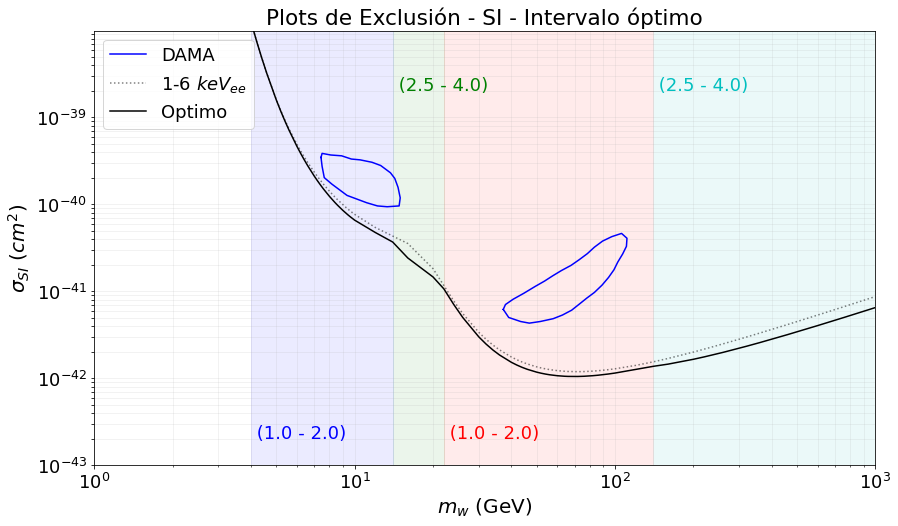

In [19]:
import itertools
plt.figure(figsize=(14, 8), facecolor='white')  # Fondo blanco de la figura
ax = plt.subplot()
ax.set_facecolor('white')  # Fondo blanco del área de los ejes

ax.plot(DAMA1_x,DAMA1_y,c='blue',label="DAMA")
ax.plot(DAMA2_x,DAMA2_y,c='blue')

#ax.plot(COSINE_x,COSINE_y,c='black',linestyle="--",label="COSINE (2018)")


ax.plot(DM_16_m,DM_16, linestyle=':',label="1-6 $keV_{ee}$",c="black",alpha=0.5)
#ax.plot(DM_16_ANOD_m,DM_16_ANOD , linestyle=':', label="1-6 $keV_{ee}$- ALE",c="green",alpha=0.5)
ax.plot(masas_opt,sigmas_opt, linestyle='-', label="Optimo", alpha=1,c="black")
#ax.plot(masas_opt_ANOD,sigmas_opt_ANOD, linestyle='-', label="Optimo - ANOD", alpha=1,c="green")




ax.set_title(r'Plots de Exclusión - SI - Intervalo óptimo')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-38
y_inf=1e-43

listcolors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
color_cycle = itertools.cycle(listcolors)
ax.legend(loc="upper left")
for i in range (5,len(i_crit)):
    col=next(color_cycle)
    ax.axvspan(m_crit[i][0],m_crit[i][1],alpha=0.08,color=col,label="("+f"{i_crit[i][0]}"+" - "+f"{i_crit[i][1]}"+") "+" $keV_{ee}$")
    ax.text(m_crit[i][0],2e-43*(1+(i+1)%2*10000)," ("+f"{i_crit[i][0]}"+" - "+f"{i_crit[i][1]}"+") ",ha="left",color=col)


ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

plt.savefig("SinFondoSI_5.svg", dpi=150, facecolor='white')


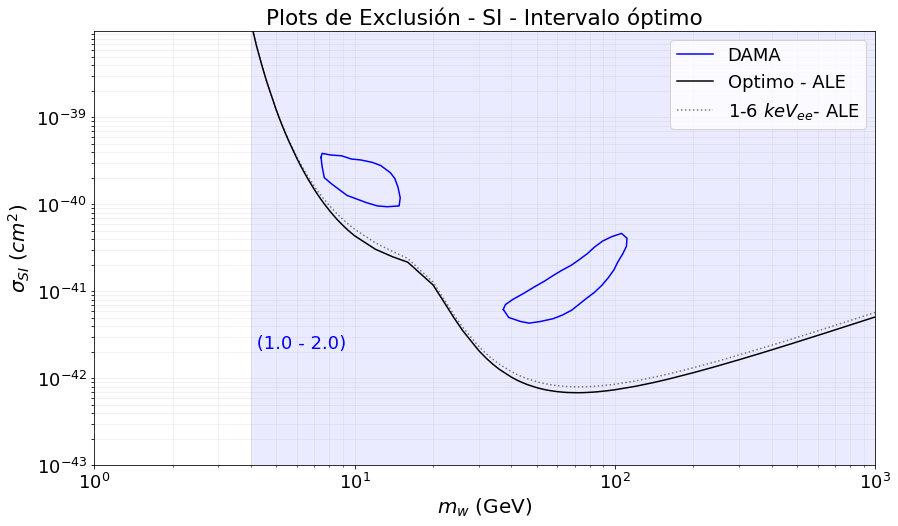

In [20]:
import itertools
plt.figure(figsize=(14, 8), facecolor='white')  # Fondo blanco de la figura
ax = plt.subplot()
ax.set_facecolor('white')  # Fondo blanco del área de los ejes

ax.plot(DAMA1_x,DAMA1_y,c='blue',label="DAMA")
ax.plot(DAMA2_x,DAMA2_y,c='blue')



#ax.plot(masas_opt,sigmas_opt, linestyle='-', label="Optimo", alpha=1,c="red")
ax.plot(masas_opt_ANOD,sigmas_opt_ANOD, linestyle='-', label="Optimo - ALE", alpha=1,c="black")

ax.plot(DM_16_ANOD_m,DM_16_ANOD , linestyle=':', label="1-6 $keV_{ee}$- ALE",c="black",alpha=0.5)

#ax.plot(COSINE_x,COSINE_y,c='black',linestyle="--",label="COSINE (2018)")



ax.set_title(r'Plots de Exclusión - SI - Intervalo óptimo')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-38
y_inf=1e-43

listcolors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
color_cycle = itertools.cycle(listcolors)
ax.legend()
for i in range (1,len(i_crit_ANOD)):
    col=next(color_cycle)
    ax.axvspan(m_crit_ANOD[i][0],m_crit_ANOD[i][1],alpha=0.08,color=col,label="("+f"{i_crit_ANOD[i][0]}"+" - "+f"{i_crit_ANOD[i][1]}"+") "+" $keV_{ee}$")
    ax.text(m_crit_ANOD[i][0],2e-43*(1+(i)%2*10)," ("+f"{i_crit_ANOD[i][0]}"+" - "+f"{i_crit_ANOD[i][1]}"+") ",ha="left",color=col)


ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

plt.savefig("SinFondoSI_6.svg", dpi=150, facecolor='white')


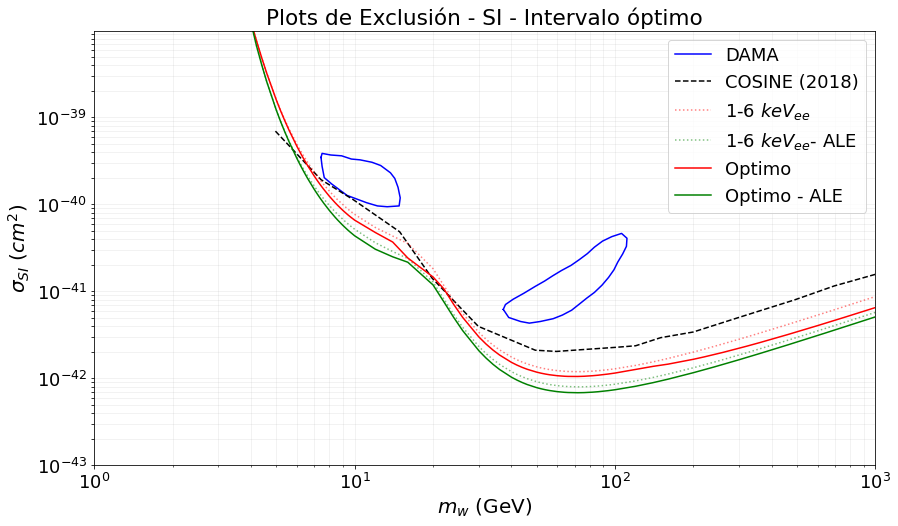

In [21]:
plt.figure(figsize=(14, 8), facecolor='white')  # Fondo blanco de la figura
ax = plt.subplot()
ax.set_facecolor('white')  # Fondo blanco del área de los ejes

ax.plot(DAMA1_x,DAMA1_y,c='blue',label="DAMA")
ax.plot(DAMA2_x,DAMA2_y,c='blue')

ax.plot(COSINE_x,COSINE_y,c='black',linestyle="--",label="COSINE (2018)")

ax.plot(DM_16_m,DM_16, linestyle=':',label="1-6 $keV_{ee}$",c="red",alpha=0.5)
ax.plot(DM_16_ANOD_m,DM_16_ANOD , linestyle=':', label="1-6 $keV_{ee}$- ALE",c="green",alpha=0.5)



ax.plot(masas_opt,sigmas_opt, linestyle='-', label="Optimo", alpha=1,c="red")
ax.plot(masas_opt_ANOD,sigmas_opt_ANOD, linestyle='-', label="Optimo - ALE", alpha=1,c="green")

#ax.plot(DM_26_m,DM_26, linestyle='--',label="2-6", alpha=1,c="red")
#ax.plot(DM_26_ANOD_m,DM_26_ANOD , linestyle='--', label="2-6 - ANOD", alpha=1,c="green")

ax.legend()

ax.set_title(r'Plots de Exclusión - SI - Intervalo óptimo')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-38
y_inf=1e-43

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

plt.savefig("SinFondoSI_7.svg", dpi=150, facecolor='white')
